In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import shap
from sklearn.pipeline import Pipeline
import joblib


In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
df.info

<bound method DataFrame.info of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   5

In [5]:
df.shape

(768, 9)

In [6]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [7]:
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [8]:
df.notnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...
763,True,True,True,True,True,True,True,True,True
764,True,True,True,True,True,True,True,True,True
765,True,True,True,True,True,True,True,True,True
766,True,True,True,True,True,True,True,True,True


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


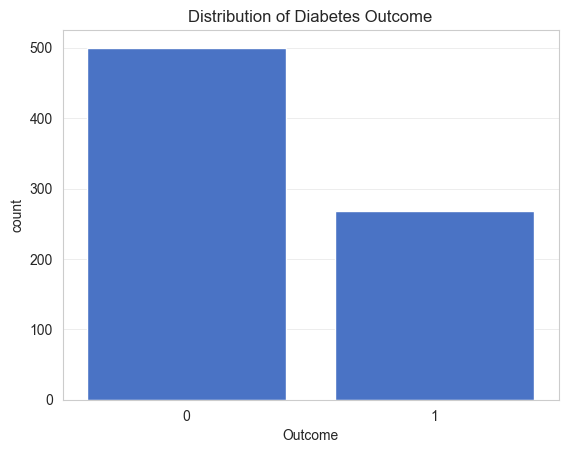

In [10]:
sns.set_style('whitegrid')
ax = sns.countplot(x='Outcome', data=df)
ax.set_title('Distribution of Diabetes Outcome')
plt.show()

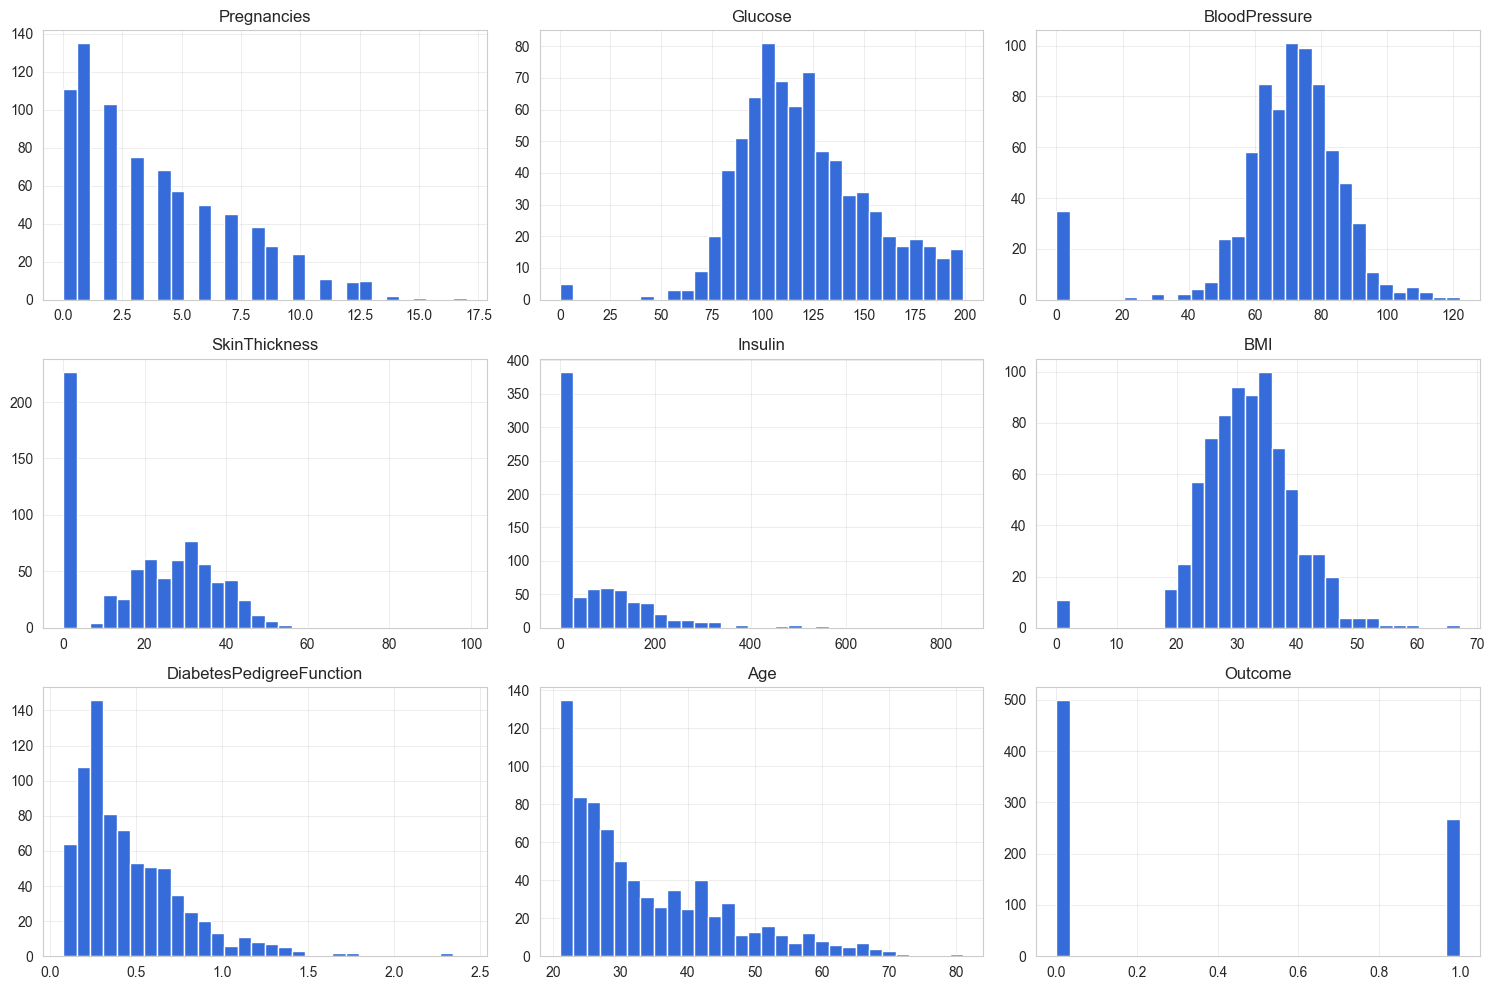

In [11]:
df.hist(figsize=(15, 10), bins=30, layout=(3,3))
plt.tight_layout()
plt.show()


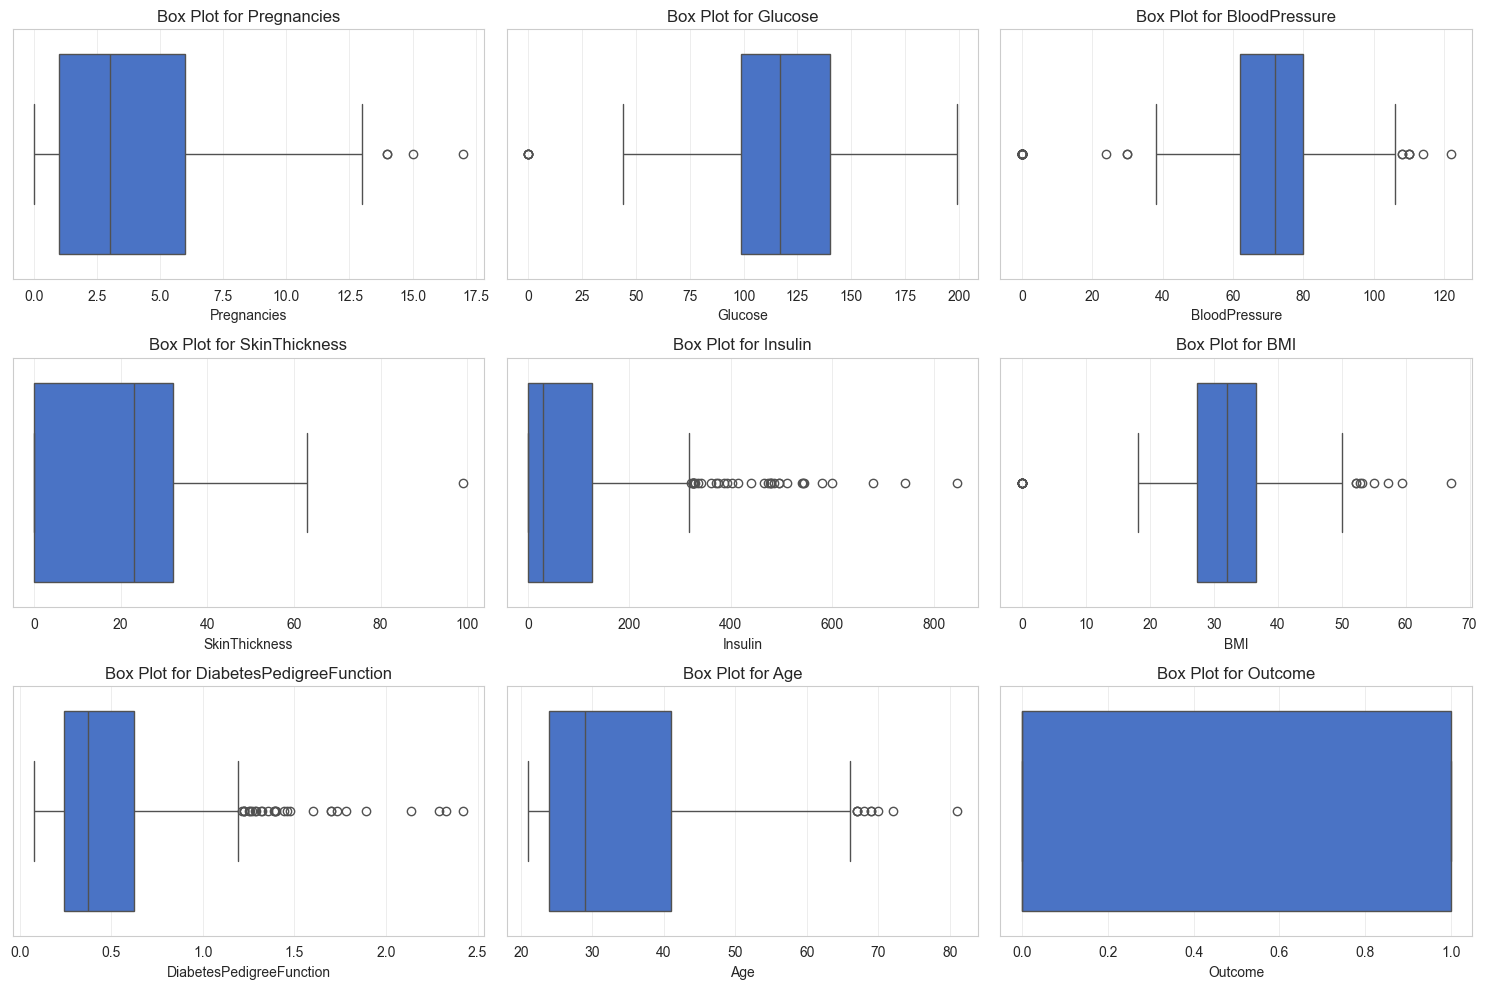

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), df.columns):
    sns.boxplot(x=col, data=df, ax=ax)
    ax.set_title(f'Box Plot for {col}')
plt.tight_layout()
plt.show()

In [13]:
correlation_matrix = df.corr()
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


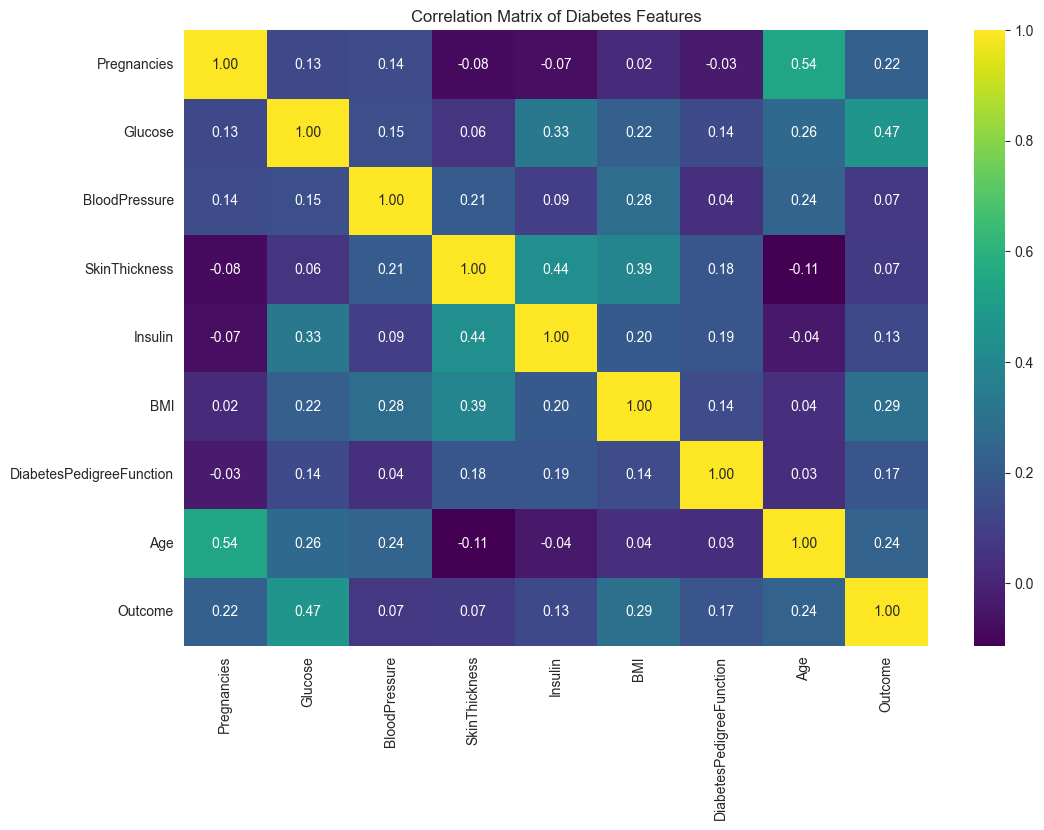

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Diabetes Features')
plt.show()

In [15]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("A peek at the data in the identified columns:")
df[columns_with_zeros].head()

A peek at the data in the identified columns:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148,72,35,0,33.6
1,85,66,29,0,26.6
2,183,64,0,0,23.3
3,89,66,23,94,28.1
4,137,40,35,168,43.1


In [16]:
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)
print("Data after replacing 0s with NaN:")
df.head()

Data after replacing 0s with NaN:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [17]:
missing_values_count = df.isnull().sum()
print("Count of missing values in each column after cleaning:")
print(missing_values_count)

Count of missing values in each column after cleaning:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [18]:
imputer = SimpleImputer(strategy='median')
imputed_data_array = imputer.fit_transform(df)
df_imputed = pd.DataFrame(imputed_data_array, columns=df.columns)
print("Missing values after imputation:")
print(df_imputed.isnull().sum())
print("\nData after imputation:")
print(df_imputed.head())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data after imputation:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    125.0  33.6   
1          1.0     85.0           66.0           29.0    125.0  26.6   
2          8.0    183.0           64.0           29.0    125.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.627  50.0      1.0  
1                     0.351  31.0      0.0  
2                     0.672  32.0      1.0  
3                     0.167  21.0      0.0  
4 

In [19]:
df = df_imputed

In [20]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print("First 5 rows of our features (X):")
print(X.head())
print("First 5 rows of our taget (y):")
print(y.head())

First 5 rows of our features (X):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    125.0  33.6   
1          1.0     85.0           66.0           29.0    125.0  26.6   
2          8.0    183.0           64.0           29.0    125.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  
0                     0.627  50.0  
1                     0.351  31.0  
2                     0.672  32.0  
3                     0.167  21.0  
4                     2.288  33.0  
First 5 rows of our taget (y):
0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Outcome, dtype: float64


In [21]:
print(f"\nShape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


Shape of X: (768, 8)
Shape of y: (768,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Shape of original X:", X.shape)
print("Shape of original y:", y.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of original X: (768, 8)
Shape of original y: (768,)
Shape of X_train: (614, 8)
Shape of y_train: (614,)
Shape of X_test: (154, 8)
Shape of y_test: (154,)


In [23]:
scaler = StandardScaler()
print("StandardScaler object created successfully:")
print(scaler)

StandardScaler object created successfully:
StandardScaler()


In [24]:
scaler.fit(X_train)
print("Learned Mean values for each feature (from X_train):")
print(scaler.mean_)
print("\nLearned Standard Deviation values for each feature (from X_train):")
print(scaler.scale_)

Learned Mean values for each feature (from X_train):
[  3.81921824 121.67100977  72.14006515  29.04234528 137.70521173
  32.44674267   0.47742834  33.36644951]

Learned Standard Deviation values for each feature (from X_train):
[ 3.31144822 29.97935076 12.26511926  8.88461128 78.70059997  6.81858312
  0.33003119 11.8237979 ]


In [25]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [26]:
print("First 5 rows of scaled training data (X_train_scaled):")
print(X_train_scaled.head())
print("\nStatistical summary of scaled training data:")
print(X_train_scaled.describe())

First 5 rows of scaled training data (X_train_scaled):
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.851355 -1.056427      -0.826740      -1.918187 -1.203361 -0.769477   
1     0.356576  0.144399       0.477772      -0.229874 -1.470195 -0.417498   
2    -0.549372 -0.556083      -1.152868       1.233330 -0.555335  0.359790   
3    -0.851355  0.811525      -1.315932      -0.004766 -0.161437 -0.402832   
4    -1.153338 -0.889646      -0.663676       1.120776 -0.415565  1.782373   

   DiabetesPedigreeFunction       Age  
0                  0.310794 -0.792169  
1                 -0.116439  0.561034  
2                 -0.764862 -0.707594  
3                  0.262314 -0.369293  
4                 -0.337630 -0.961320  

Statistical summary of scaled training data:
        Pregnancies       Glucose  BloodPressure  SkinThickness       Insulin  \
count  6.140000e+02  6.140000e+02   6.140000e+02   6.140000e+02  6.140000e+02   
mean  -6.943414e-17 -1.09937

In [27]:
log_reg = LogisticRegression(random_state=42)
print(log_reg)

LogisticRegression(random_state=42)


In [28]:
log_reg.fit(X_train_scaled, y_train)
print(log_reg)

LogisticRegression(random_state=42)


In [29]:
knn = KNeighborsClassifier(n_neighbors=5)
print(knn)

KNeighborsClassifier()


In [30]:
knn.fit(X_train_scaled, y_train)
print(knn)

KNeighborsClassifier()


In [31]:
y_pred_log_reg = log_reg.predict(X_test_scaled)
print("First 20 predictions from the Logistic Regression model:")
print(y_pred_log_reg[:20])
print("First 20 True Output:")
print(y_test[:20].values)

First 20 predictions from the Logistic Regression model:
[1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]
First 20 True Output:
[0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0.]


--- Logistic Regression Classification Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.75      0.82      0.78       100
    Diabetic (1)       0.60      0.50      0.55        54

        accuracy                           0.71       154
       macro avg       0.68      0.66      0.67       154
    weighted avg       0.70      0.71      0.70       154

\n--- Logistic Regression Confusion Matrix ---
[[82 18]
 [27 27]]


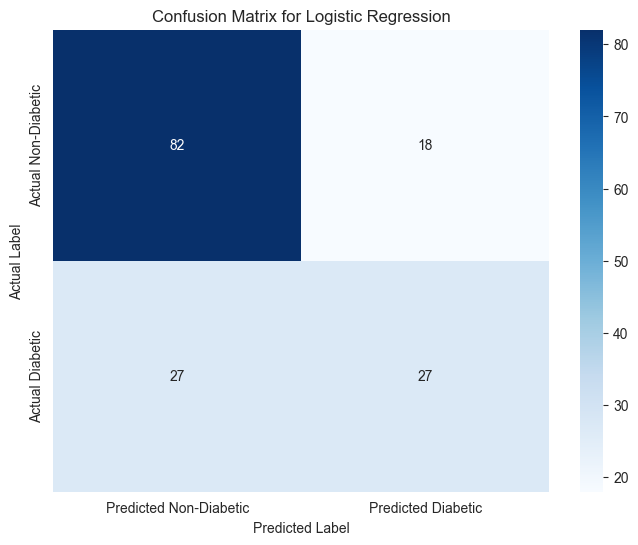

In [32]:
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

print("\\n--- Logistic Regression Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_log_reg)
print(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()


In [33]:
y_pred_knn = knn.predict(X_test_scaled)
print("First 20 predictions from the k-NN model:")
print(y_pred_knn[:20])

print("\nFirst 20 true labels (y_test):")
print(y_test[:20].values)

print("\n First 20 predictions from the Logistic Regression model:")
print(y_pred_log_reg[:20])

First 20 predictions from the k-NN model:
[1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0.]

First 20 true labels (y_test):
[0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0.]

 First 20 predictions from the Logistic Regression model:
[1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]


--- K-Nearest Neighbors (k-NN) Classification Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.80      0.83      0.81       100
    Diabetic (1)       0.66      0.61      0.63        54

        accuracy                           0.75       154
       macro avg       0.73      0.72      0.72       154
    weighted avg       0.75      0.75      0.75       154


--- K-Nearest Neighbors (k-NN) Confusion Matrix ---


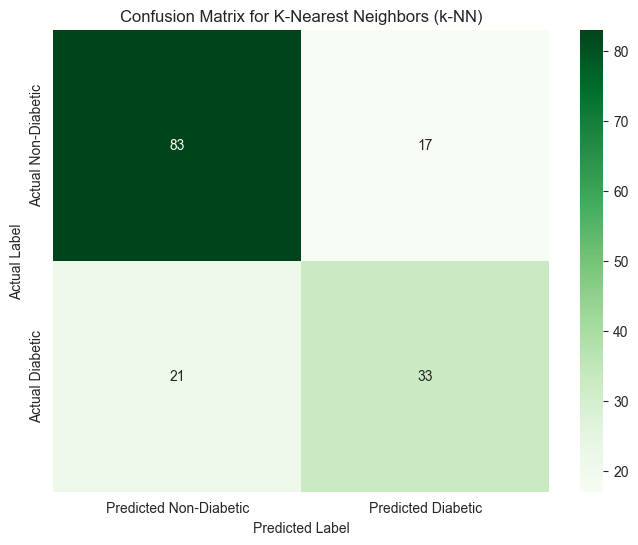

In [34]:
print("--- K-Nearest Neighbors (k-NN) Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

print("\n--- K-Nearest Neighbors (k-NN) Confusion Matrix ---")
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Greens', # Using a different color map to visually distinguish from the last plot
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for K-Nearest Neighbors (k-NN)')
plt.show()

In [35]:
report_knn = classification_report(y_test, y_pred_knn, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
report_log_reg = classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
f1_log_reg = report_log_reg['Diabetic (1)']['f1-score']
f1_knn = report_knn['Diabetic (1)']['f1-score']

In [36]:
print(f"--- F1-Score Comparison ---")
print(f"Logistic Regression F1-Score (Diabetic Class): {f1_log_reg:.4f}")
print(f"K-Nearest Neighbors F1-Score (Diabetic Class): {f1_knn:.4f}")

print("\\n--- Initial Conclusion ---")
if f1_log_reg > f1_knn:
    print("Based on the F1-Score, the Logistic Regression model is the initial best performer.")
elif f1_knn > f1_log_reg:
    print("Based on the F1-Score, the K-Nearest Neighbors model is the initial best performer.")
else:
    print("Based on the F1-Score, both models have nearly identical performance.")

--- F1-Score Comparison ---
Logistic Regression F1-Score (Diabetic Class): 0.5455
K-Nearest Neighbors F1-Score (Diabetic Class): 0.6346
\n--- Initial Conclusion ---
Based on the F1-Score, the K-Nearest Neighbors model is the initial best performer.


In [37]:
tn_log_reg = cm[0, 0]
fp_log_reg = cm[0, 1]
fn_log_reg = cm[1, 0]
tp_log_reg = cm[1, 1]

tn_knn = cm_knn[0, 0]
fp_knn = cm_knn[0, 1]
fn_knn = cm_knn[1, 0]
tp_knn = cm_knn[1, 1]

print("--- Error Analysis: Logistic Regression vs. k-NN ---")
print("\\n--- Logistic Regression ---")
print(f"False Positives (Predicted Diabetic, Was Healthy): {fp_log_reg}")
print(f"False Negatives (Predicted Healthy, Was Diabetic): {fn_log_reg}  <-- MOST CRITICAL ERROR")

print("\\n--- K-Nearest Neighbors ---")
print(f"False Positives (Predicted Diabetic, Was Healthy): {fp_knn}")
print(f"False Negatives (Predicted Healthy, Was Diabetic): {fn_knn}  <-- MOST CRITICAL ERROR")

print("\\n--- Final Conclusion ---")
if fn_log_reg < fn_knn:
    print(f"The Logistic Regression model is the superior baseline.")
    print(f"It produced {fn_knn - fn_log_reg} fewer False Negatives, which is our primary concern.")
elif fn_knn < fn_log_reg:
    print(f"The K-Nearest Neighbors model is the superior baseline.")
    print(f"It produced {fn_log_reg - fn_knn} fewer False Negatives, which is our primary concern.")
else:
    print("Both models produced the same number of False Negatives.")
    print("We can fall back to the F1-score to make our final decision.")

--- Error Analysis: Logistic Regression vs. k-NN ---
\n--- Logistic Regression ---
False Positives (Predicted Diabetic, Was Healthy): 18
False Negatives (Predicted Healthy, Was Diabetic): 27  <-- MOST CRITICAL ERROR
\n--- K-Nearest Neighbors ---
False Positives (Predicted Diabetic, Was Healthy): 17
False Negatives (Predicted Healthy, Was Diabetic): 21  <-- MOST CRITICAL ERROR
\n--- Final Conclusion ---
The K-Nearest Neighbors model is the superior baseline.
It produced 6 fewer False Negatives, which is our primary concern.


In [38]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [39]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)


C:\Users\Phoenix\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [18:39:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


--- Random Forest Classifier Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.81      0.87      0.84       100
    Diabetic (1)       0.72      0.61      0.66        54

        accuracy                           0.78       154
       macro avg       0.76      0.74      0.75       154
    weighted avg       0.77      0.78      0.77       154


--- Random Forest Confusion Matrix ---


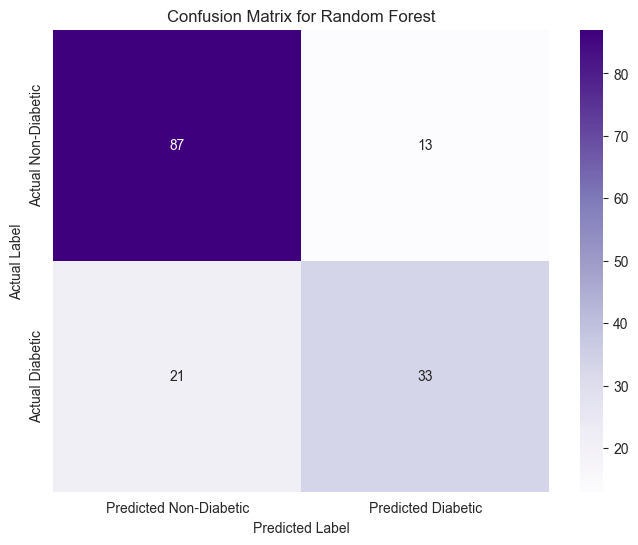

In [40]:
y_pred_rf = rf_model.predict(X_test_scaled)
print("--- Random Forest Classifier Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))
print("\n--- Random Forest Confusion Matrix ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Purples', # Using a new color map to distinguish from baselines
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Random Forest')
plt.show()



--- XGBoost Classifier Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.81      0.83      0.82       100
    Diabetic (1)       0.67      0.63      0.65        54

        accuracy                           0.76       154
       macro avg       0.74      0.73      0.73       154
    weighted avg       0.76      0.76      0.76       154


--- XGBoost Confusion Matrix ---


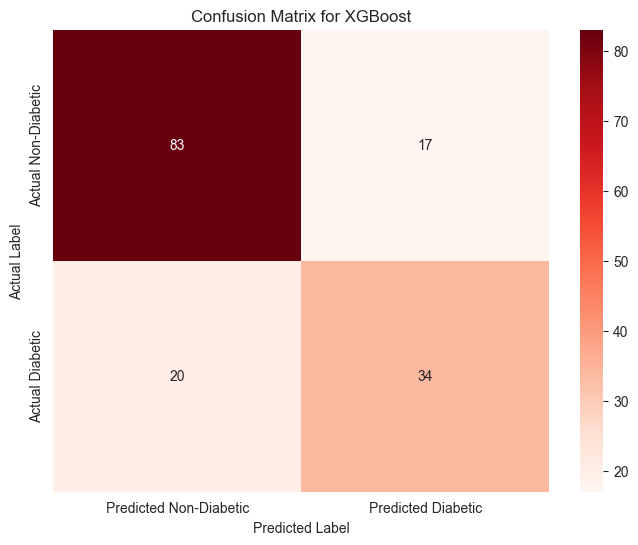

In [41]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
print("\n\n--- XGBoost Classifier Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))
print("\n--- XGBoost Confusion Matrix ---")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb,
            annot=True,
            fmt='d',
            cmap='Reds', # Another distinct color map
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for XGBoost')
plt.show()

In [42]:
report_rf = classification_report(y_test, y_pred_rf, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
performance_summary = {
    'Logistic Regression': {
        'Precision': report_log_reg['Diabetic (1)']['precision'],
        'Recall': report_log_reg['Diabetic (1)']['recall'],
        'F1-Score': report_log_reg['Diabetic (1)']['f1-score'],
    },
    'K-Nearest Neighbors': {
        'Precision': report_knn['Diabetic (1)']['precision'],
        'Recall': report_knn['Diabetic (1)']['recall'],
        'F1-Score': report_knn['Diabetic (1)']['f1-score'],
    },
    'Random Forest': {
        'Precision': report_rf['Diabetic (1)']['precision'],
        'Recall': report_rf['Diabetic (1)']['recall'],
        'F1-Score': report_rf['Diabetic (1)']['f1-score'],
    },
    'XGBoost': {
        'Precision': report_xgb['Diabetic (1)']['precision'],
        'Recall': report_xgb['Diabetic (1)']['recall'],
        'F1-Score': report_xgb['Diabetic (1)']['f1-score'],
    }
}

all_cms = {
    'Logistic Regression': cm,
    'K-Nearest Neighbors': cm_knn,
    'Random Forest': cm_rf,
    'XGBoost': cm_xgb
}

for model_name, model_cm in all_cms.items():
    performance_summary[model_name]['False Positives'] = model_cm[0, 1]
    performance_summary[model_name]['False Negatives'] = model_cm[1, 0]

performance_df = pd.DataFrame.from_dict(performance_summary, orient='index')
performance_df = performance_df[['F1-Score', 'Recall', 'Precision', 'False Negatives', 'False Positives']]
display(performance_df.style.background_gradient(cmap='viridis', subset=['F1-Score', 'Recall'])
                          .highlight_min(subset=['False Negatives'], color='lightcoral'))

,F1-Score,Recall,Precision,False Negatives,False Positives
Logistic Regression,0.545455,0.500000,0.600000,27,18
K-Nearest Neighbors,0.634615,0.611111,0.660000,21,17
Random Forest,0.660000,0.611111,0.717391,21,13
XGBoost,0.647619,0.629630,0.666667,20,17


In [43]:
best_model = xgb_model
best_model_name = "XGBoost"

In [44]:
param_grid_xgb = {
    # n_estimators: Number of trees in the forest. We test a few different sizes.
    'n_estimators': [100, 200, 300],

    # max_depth: The maximum depth of a tree. We test shallow (3), medium (5), and deeper (7) trees.
    # This directly controls the model's complexity and its risk of overfitting.
    'max_depth': [3, 5, 7],

    # learning_rate: Step size shrinkage. A smaller value makes the model more robust.
    # We test a standard value and two smaller ones.
    'learning_rate': [0.01, 0.1, 0.2],

    # subsample: Fraction of training instances to be randomly sampled for each tree.
    # This helps to prevent overfitting. We test values that use most, but not all, of the data.
    'subsample': [0.7, 0.8, 0.9],

    # colsample_bytree: Fraction of columns to be randomly sampled for each tree.
    'colsample_bytree': [0.7, 0.8, 0.9]
}


In [45]:
num_combinations = 1
for key in param_grid_xgb:
    num_combinations *= len(param_grid_xgb[key])
print(f"\nTotal number of combinations to test: {num_combinations}")


Total number of combinations to test: 243


In [46]:
grid_search = GridSearchCV(
    estimator=best_model,        # The model to tune (our selected best performer).
    param_grid=param_grid_xgb,   # The dictionary of hyperparameters to test.
    scoring='f1',                # The metric to use for evaluation. 'f1' is great for imbalanced classification.
    cv=5,                        # Use 5-fold cross-validation.
    n_jobs=-1,                   # Use all available CPU cores to speed up the process.
    verbose=2                    # Print detailed progress updates during the search.
)

print("--- GridSearchCV Tuning Engine Assembled and Ready ---")
print(grid_search)

--- GridSearchCV Tuning Engine Assembled and Ready ---
GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
 

In [47]:
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


C:\Users\Phoenix\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [18:40:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_

In [48]:
print("--- Optimal Hyperparameters Found by Grid Search ---")
best_params = grid_search.best_params_
print(best_params)

--- Optimal Hyperparameters Found by Grid Search ---
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}


In [49]:
best_cv_score = grid_search.best_score_
try:
    original_f1_score = performance_df.loc[best_model_name, 'F1-Score']

    print(f"\n--- Performance Improvement Analysis ---")
    print(f"Original, untuned model's F1-score on the test set: {original_f1_score:.4f}")
    print(f"Tuned model's cross-validation F1-score: {best_cv_score:.4f}")

    improvement = best_cv_score - original_f1_score
    print(f"Improvement from hyperparameter tuning: {improvement:+.4f}")

except NameError:
    print("\nRun the previous steps to create 'performance_df' and 'best_model_name' for a full comparison.")


--- Performance Improvement Analysis ---
Original, untuned model's F1-score on the test set: 0.6476
Tuned model's cross-validation F1-score: 0.6499
Improvement from hyperparameter tuning: +0.0022


--- The Final Tuned Model ---
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


--- Final Tuned Model Classification Report (on Test Set) ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.77      0.84      0.80       100
    Diabetic (1

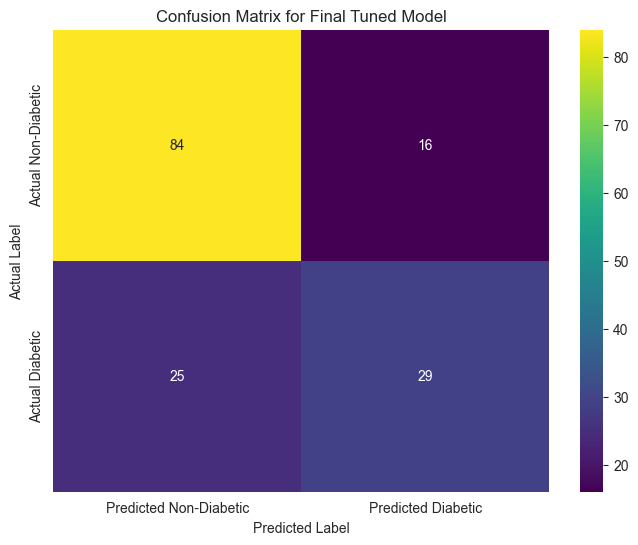

In [50]:
final_model = grid_search.best_estimator_
print("--- The Final Tuned Model ---")
print(final_model)
y_pred_final = final_model.predict(X_test_scaled)
print("\n\n--- Final Tuned Model Classification Report (on Test Set) ---")

report_final = classification_report(y_test, y_pred_final, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
print(classification_report(y_test, y_pred_final, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

print("\n--- Final Tuned Model Confusion Matrix (on Test Set) ---")
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_final,
            annot=True,
            fmt='d',
            cmap='viridis', # A nice, vibrant colormap for our final model
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Final Tuned Model')
plt.show()

In [51]:
final_f1 = report_final['Diabetic (1)']['f1-score']
final_recall = report_final['Diabetic (1)']['recall']
final_fn = cm_final[1, 0] # False Negatives

# Get metrics for the original, untuned model from our dashboard
# This assumes 'performance_df' and 'best_model_name' are still in memory
original_f1 = performance_df.loc[best_model_name, 'F1-Score']
original_recall = performance_df.loc[best_model_name, 'Recall']
original_fn = performance_df.loc[best_model_name, 'False Negatives']

# Create a new DataFrame for a clear, side-by-side comparison
comparison_data = {
    'Metric': ['F1-Score', 'Recall', 'False Negatives (Critical)'],
    f'Original {best_model_name}': [original_f1, original_recall, original_fn],
    f'Final Tuned {best_model_name}': [final_f1, final_recall, final_fn]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index('Metric', inplace=True)

# Display the comparison table with styling
display(comparison_df.style.format('{:.4f}', subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                          .format('{:.0f}', subset=pd.IndexSlice[['False Negatives (Critical)'], :])
                          .background_gradient(cmap='Greens', axis=1, subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                          .highlight_min(subset=pd.IndexSlice[['False Negatives (Critical)'], :], color='lightcoral', axis=1))


,Original XGBoost,Final Tuned XGBoost
Metric,,
F1-Score,0.6476,0.5859
Recall,0.6296,0.5370
False Negatives (Critical),20,25


In [52]:
importances = final_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
display(feature_importance_df.reset_index(drop=True))

,Feature,Importance
0,Glucose,0.323376
1,BMI,0.149266
2,Age,0.122280
3,Insulin,0.105949
4,Pregnancies,0.085489
5,DiabetesPedigreeFunction,0.085039
6,SkinThickness,0.081355
7,BloodPressure,0.047246


C:\Users\Phoenix\AppData\Local\Temp\ipykernel_18940\784369356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


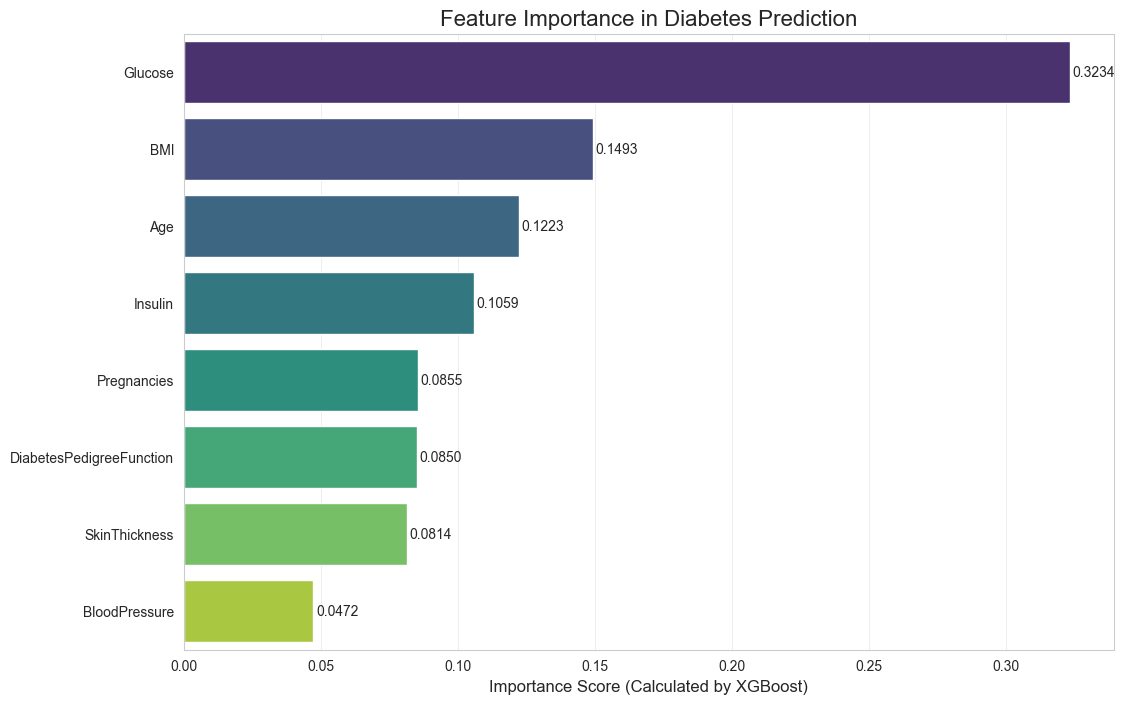

In [53]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance in Diabetes Prediction', fontsize=16)
plt.xlabel('Importance Score (Calculated by XGBoost)', fontsize=12)
plt.ylabel('')
for p in barplot.patches:
    width = p.get_width()
    plt.text(width + 0.001,  # x-position
             p.get_y() + p.get_height() / 2,
             f'{width:.4f}',
             va='center')

plt.show()

In [54]:
explainer = shap.TreeExplainer(final_model)
print(type(explainer))

<class 'shap.explainers._tree.TreeExplainer'>


In [58]:
shap_values = explainer(X_test_scaled)
print("Type of the output:", type(shap_values))

print("\nShape of the SHAP values array:", shap_values.values.shape)
print(f"This means we have {shap_values.values.shape[0]} explanations (one for each test patient),")
print(f"and each explanation has {shap_values.values.shape[1]} values (one for each feature).")

# You can also inspect the first row of SHAP values to see the explanation for the first patient in the test set.
print("\nSHAP values for the first patient in the test set:")
print(shap_values.values[0])

# The Explanation object also contains the original data used for the explanation.
print("\nOriginal feature values for the first patient:")
print(shap_values.data[0])

Type of the output: <class 'shap._explanation.Explanation'>

Shape of the SHAP values array: (154, 8)
This means we have 154 explanations (one for each test patient),
and each explanation has 8 values (one for each feature).

SHAP values for the first patient in the test set:
[ 0.17422     1.4207492  -0.00204737 -0.00723131  0.0788203  -0.4092937
 -0.12585284  0.29247394]

Original feature values for the first patient:
[ 0.96054099  1.24515673 -0.66367599 -0.00476614 -0.16143729 -0.74014536
 -0.55579092  0.56103382]


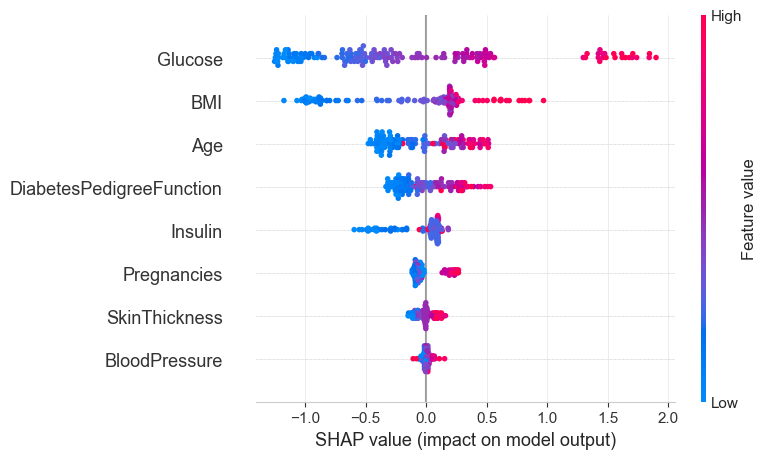

<Figure size 640x480 with 0 Axes>

In [56]:
feature_names = X.columns
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, plot_type="dot")
fig = plt.gcf()
fig.suptitle("SHAP Summary Plot for Diabetes Prediction", y=1.02, fontsize=16)

plt.show()

Plotting dependence for the most important feature: 'Glucose'
Coloring by the second most important feature: 'BMI'


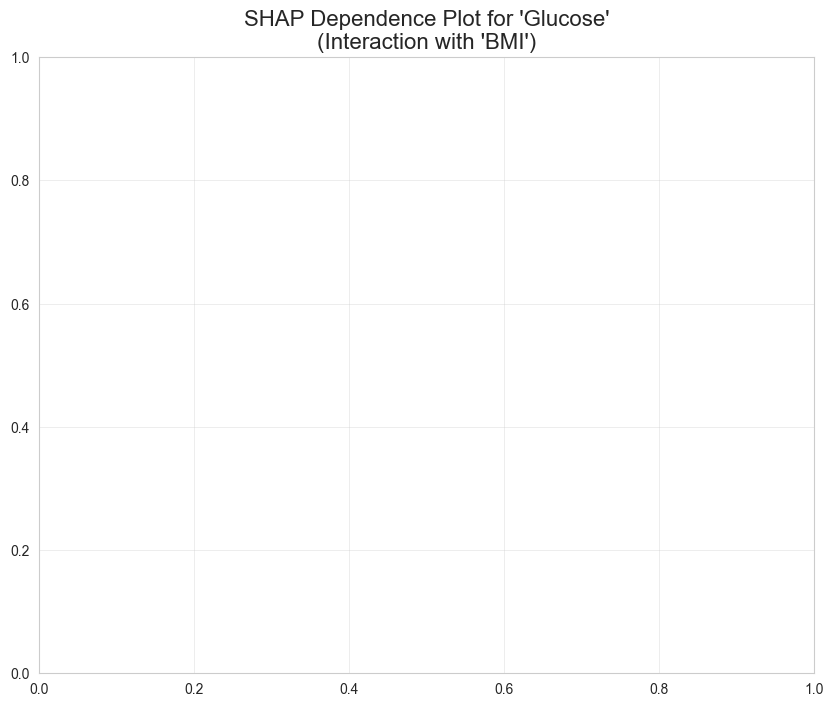

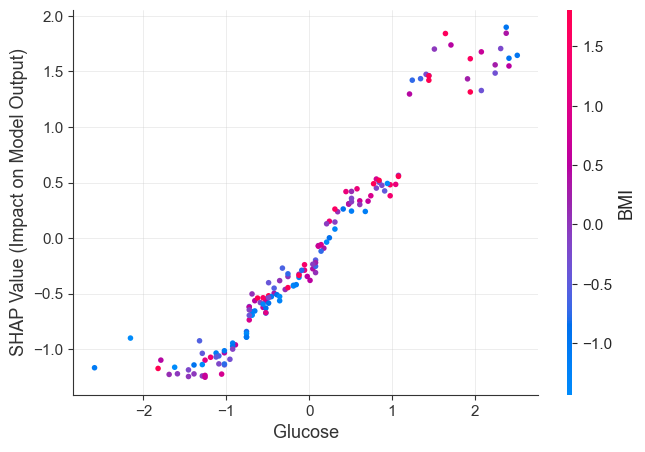

In [57]:
most_important_feature = feature_importance_df.iloc[0]['Feature']
second_most_important_feature = feature_importance_df.iloc[1]['Feature']

print(f"Plotting dependence for the most important feature: '{most_important_feature}'")
print(f"Coloring by the second most important feature: '{second_most_important_feature}'")
plt.figure(figsize=(10, 8))
plt.title(f"SHAP Dependence Plot for '{most_important_feature}'\n(Interaction with '{second_most_important_feature}')", fontsize=16)

# Create the plot
shap.dependence_plot(
    most_important_feature,
    shap_values.values, # Use the .values attribute to pass the numpy array of SHAP values
    X_test_scaled,      # Pass the DataFrame of scaled test features
    interaction_index=second_most_important_feature,
    show=False # We set show=False to customize the plot further before displaying
)

# Customize the plot for better readability
plt.ylabel("SHAP Value (Impact on Model Output)")
plt.grid(True)
plt.show()

In [60]:
try:
    final_model
except NameError:
    print("Warning: The 'final_model' variable is not defined.")
    print("Please make sure you have run the previous steps to get the best estimator from GridSearchCV.")
pipeline_steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', final_model)
]

print("--- Machine Learning Pipeline Blueprint ---")
for step in pipeline_steps:
    print(f"Step Name: '{step[0]}', Object: {step[1].__class__.__name__}")
final_pipeline = Pipeline(steps=pipeline_steps)

--- Machine Learning Pipeline Blueprint ---
Step Name: 'imputer', Object: SimpleImputer
Step Name: 'scaler', Object: StandardScaler
Step Name: 'classifier', Object: XGBClassifier


In [61]:
df = pd.read_csv('diabetes.csv')
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_impute] = df[cols_to_impute].replace(0, np.nan)
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of raw X_train:", X_train.shape)
print("Using this raw data to train the entire pipeline.")
print("\nTraining the final_pipeline...")
final_pipeline.fit(X_train, y_train)

print("\n--- Pipeline Training Complete! ---")

Shape of raw X_train: (614, 8)
Using this raw data to train the entire pipeline.

Training the final_pipeline...


C:\Users\Phoenix\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [18:57:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Pipeline Training Complete! ---


                  precision    recall  f1-score   support

Non-Diabetic (0)       0.77      0.84      0.80       100
    Diabetic (1)       0.64      0.54      0.59        54

        accuracy                           0.73       154
       macro avg       0.71      0.69      0.69       154
    weighted avg       0.73      0.73      0.73       154


--- Confusion Matrix from Pipeline ---


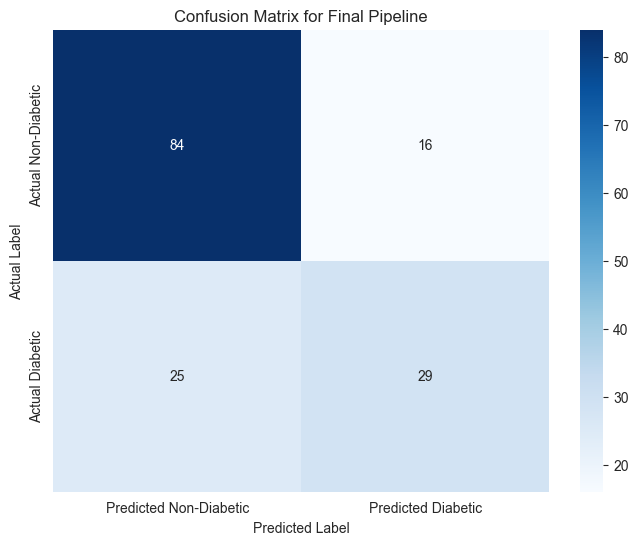



--- Sanity Check: Manual Workflow vs. Pipeline Workflow ---
{'0': {'precision': 0.7706422018348624, 'recall': 0.84, 'f1-score': 0.8038277511961722, 'support': 100.0}, '1': {'precision': 0.6444444444444445, 'recall': 0.5370370370370371, 'f1-score': 0.5858585858585859, 'support': 54.0}, 'accuracy': 0.7337662337662337, 'macro avg': {'precision': 0.7075433231396535, 'recall': 0.6885185185185185, 'f1-score': 0.694843168527379, 'support': 154.0}, 'weighted avg': {'precision': 0.7263910401525081, 'recall': 0.7337662337662337, 'f1-score': 0.7273970049089666, 'support': 154.0}}


,Original XGBoost,Final Tuned XGBoost,Pipeline Workflow
Metric,,,
F1-Score,0.6476,0.5859,0.5859
Recall,0.6296,0.5370,0.5370
False Negatives (Critical),20,25,25



Verification Result: The performance metrics should be IDENTICAL between the 'Final Tuned' model and the 'Pipeline'.
This proves our pipeline correctly encapsulates the entire workflow!


In [66]:
y_pred_pipeline = final_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_pipeline, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))
print("\n--- Confusion Matrix from Pipeline ---")
cm_pipeline = confusion_matrix(y_test, y_pred_pipeline)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pipeline,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Final Pipeline')
plt.show()

print("\n\n--- Sanity Check: Manual Workflow vs. Pipeline Workflow ---")
print(classification_report(y_test, y_pred_pipeline, output_dict=True))

try:
    pipeline_f1 = classification_report(y_test, y_pred_pipeline, output_dict=True)['1']['f1-score']
    pipeline_recall = classification_report(y_test, y_pred_pipeline, output_dict=True)['1']['recall']
    pipeline_fn = cm_pipeline[1, 0] # False Negatives

    verification_df = comparison_df.copy()
    verification_df['Pipeline Workflow'] = [pipeline_f1, pipeline_recall, pipeline_fn]

    display(verification_df.style.format('{:.4f}', subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                             .format('{:.0f}', subset=pd.IndexSlice[['False Negatives (Critical)'], :])
                             .background_gradient(cmap='Greens', axis=1, subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                             .highlight_min(subset=pd.IndexSlice[['False Negatives (Critical)'], :], color='lightcoral', axis=1))

    print("\nVerification Result: The performance metrics should be IDENTICAL between the 'Final Tuned' model and the 'Pipeline'.")
    print("This proves our pipeline correctly encapsulates the entire workflow!")

except NameError:
    print("\n'comparison_df' not found. Please ensure you have run the final task of the 'Hyperparameter Tuning' step.")

In [69]:
pipeline_filename = "diabetes_pipeline.joblib"
joblib.dump(final_pipeline, pipeline_filename)
loaded_pipeline = joblib.load(pipeline_filename)
sample_patient = X_test.iloc[[0]]
prediction = loaded_pipeline.predict(sample_patient)
prediction_probability = loaded_pipeline.predict_proba(sample_patient)
display(sample_patient)
print(f"\nModel Prediction (0=Non-Diabetic, 1=Diabetic): {prediction[0]}")
print(f"Prediction Probabilities (for [Non-Diabetic, Diabetic]): {prediction_probability[0]}")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40



Model Prediction (0=Non-Diabetic, 1=Diabetic): 1
Prediction Probabilities (for [Non-Diabetic, Diabetic]): [0.30593473 0.6940653 ]
